In [12]:
%load_ext autoreload
%autoreload 2

from typing import Literal
from itertools import combinations
from tqdm import tqdm
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import yaml
import seaborn as sns

from gcfm.priordata_processing.Datasets.ObservationalDataset import ObservationalDataset

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
def index_generator(start=0, step=1):
    index = start
    while True:
        yield index
        index += step

idxs = index_generator()

In [14]:
config = yaml.safe_load(open('../../Graphs4CausalFoundationModels/experiments/Predictive/configs/predictive.yaml', 'r')) 
scm_config = config['scm_config']
dataset_config = config['dataset_config']
preprocessing_config = config['preprocessing_config']

# default_overrides
dataset_overrides = {
    'return_adjacency_matrix': False,
    'return_moralized_matrix': True,
    'dataset_size': 1000,
    # 'max_number_samples_per_dataset': cfg.max_seq_len,  # make sure to also update in default.yaml
    # 'max_number_features': cfg.max_features,
}
for k, v in dataset_overrides.items():
    dataset_config[k] = {'value': v}

In [27]:
dataset = ObservationalDataset(
    scm_config=scm_config,
    preprocessing_config=preprocessing_config,
    dataset_config=dataset_config,
    seed=None,
)

In [67]:
n_scms = 1000

iterator = [next(idxs)] if n_scms == 1 else range(n_scms)    

data = []
adjs = []

for i in tqdm(iterator):
    x_train, y_train, x_test, y_test, graph_info, dataset_info = dataset[i]
    adj = graph_info["moral_matrix"]
    moral_density = graph_info["moral_density"].item()
    dag_density = graph_info["adj_density"].item()

    scm = graph_info["scm"]
    processor = graph_info["processor"]
    graph = scm.dag.g

    edge_prob = graph.graph['edge_prob']
    num_nodes = graph.graph['num_nodes']

    degrees = [d for _, d in graph.degree()]

    data.append({
        'edge_prob': edge_prob,
        'num_nodes': num_nodes,
        'moral_density': moral_density,
        'dag_density': dag_density,
        'num_edges': graph.number_of_edges(),
        'avg_degree': np.mean(degrees),
        'std_degree': np.std(degrees),
        'avg_clustering': nx.average_clustering(graph),
        'transitivity': nx.transitivity(graph),
    })

    adjs.append(adj.numpy())
df = pd.DataFrame(data)

100%|██████████| 1000/1000 [00:45<00:00, 22.04it/s]


In [68]:
# df.to_csv('graph_info.csv', index=False)

# # save adjs: list[np.ndarray] as list (not array) to be comaptible with older np versions
# import pickle
# adjs_list = [adj.tolist() for adj in adjs]
# pickle.dump(adjs_list, open('adjs.pkl', 'wb'))

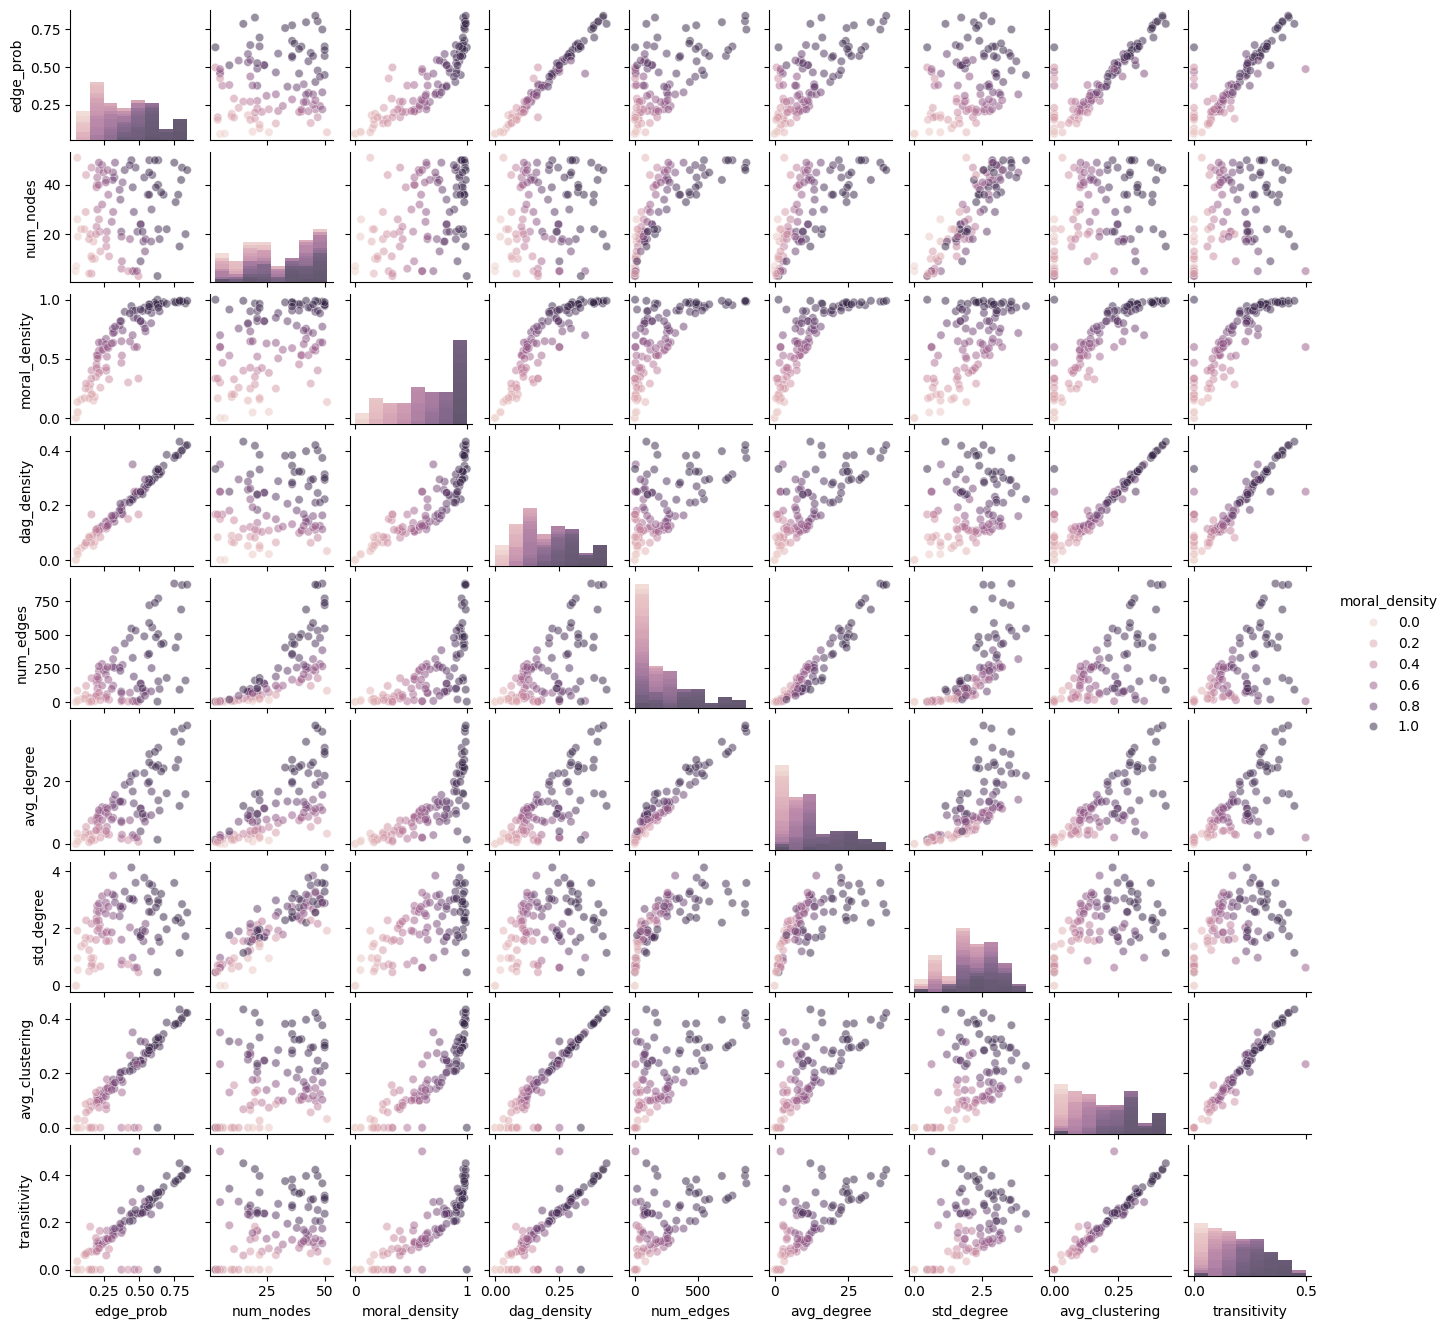

In [69]:
df_plot = df.sample(100)

g = sns.pairplot(
    df_plot,
    hue='moral_density',
    vars = df_plot.columns.tolist(),
    diag_kind = 'hist',
    height = 1.5,
    plot_kws={'alpha':0.5},
    diag_kws={'multiple': 'stack', 'linewidth': 0} 
)

In [33]:
adjs = [adj.numpy() for adj in adjs]

In [38]:
import networkx as nx
import numpy as np
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt

def graph_features(A):
    G = nx.from_numpy_array(A)
    n = G.number_of_nodes()
    m = G.number_of_edges()
    degrees = [d for _, d in G.degree()]
    
    feats = [
        n,
        m,
        nx.density(G),
        np.mean(degrees),
        np.std(degrees),
        nx.average_clustering(G),
        nx.transitivity(G),
    ]
    
    # Spectral features (top-k eigenvalues of normalized Laplacian)
    L = nx.normalized_laplacian_matrix(G).toarray()
    eigvals = np.sort(np.linalg.eigvalsh(L))[::-1]
    # Pad/truncate to fixed length
    k = 10
    spectral = np.zeros(k)
    spectral[:min(k, len(eigvals))] = eigvals[:k]
    
    return np.array(feats + list(spectral))

# Build feature matrix
X = np.array([graph_features(A) for A in adjs])

# Normalize
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)

/Users/elias/anaconda3/envs/tfm/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/elias/anaconda3/envs/tfm/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/elias/anaconda3/envs/tfm/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


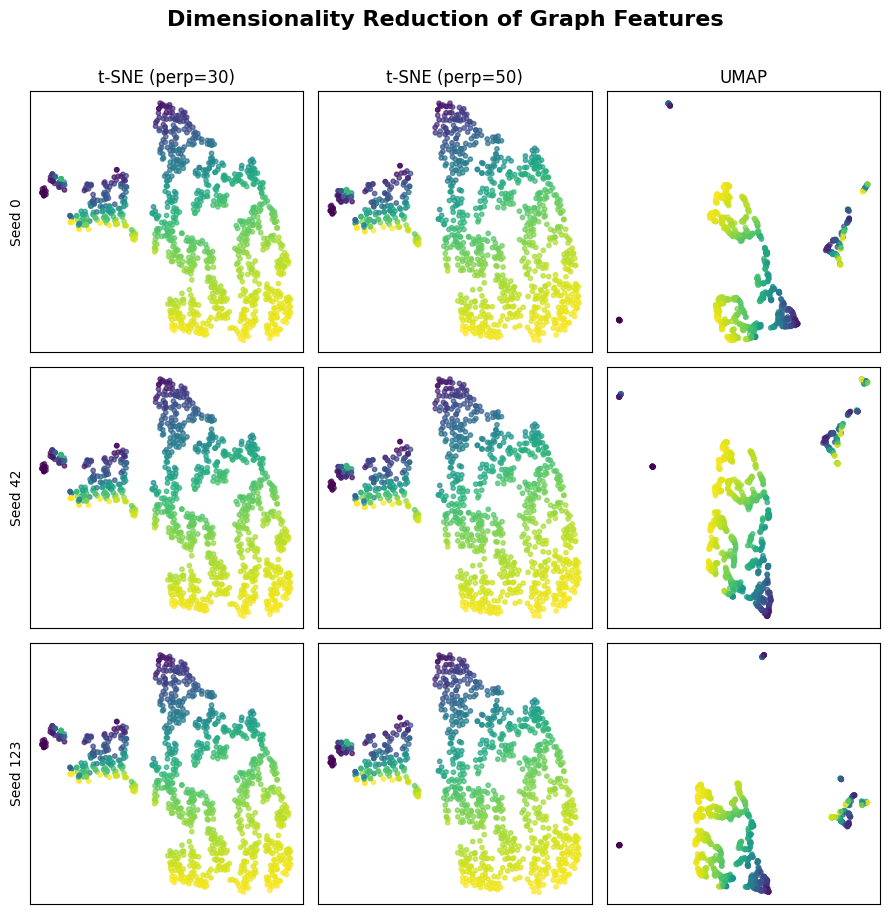

In [54]:
color = df['moral_density']  # or any other property


seeds = [0, 42, 123]
methods = {
    't-SNE (perp=30)': lambda seed: TSNE(n_components=2, perplexity=30, random_state=seed).fit_transform(X_scaled),
    't-SNE (perp=50)': lambda seed: TSNE(n_components=2, perplexity=50, random_state=seed).fit_transform(X_scaled),
    'UMAP': lambda seed: umap.UMAP(n_components=2, random_state=seed).fit_transform(X_scaled),
}

n_rows = len(seeds)
n_cols = len(methods)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))

for col, (method_name, method_fn) in enumerate(methods.items()):
    for row, seed in enumerate(seeds):
        ax = axes[row, col]
        embedding = method_fn(seed)
        sc = ax.scatter(
            embedding[:, 0], embedding[:, 1],
            s=10, c=color, cmap='viridis', alpha=0.7
        )
        ax.set_xticks([])
        ax.set_yticks([])

        if col == 0:
            ax.set_ylabel(f"Seed {seed}")
        if row == 0:
            ax.set_title(f"{method_name}")

plt.suptitle("Dimensionality Reduction of Graph Features", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


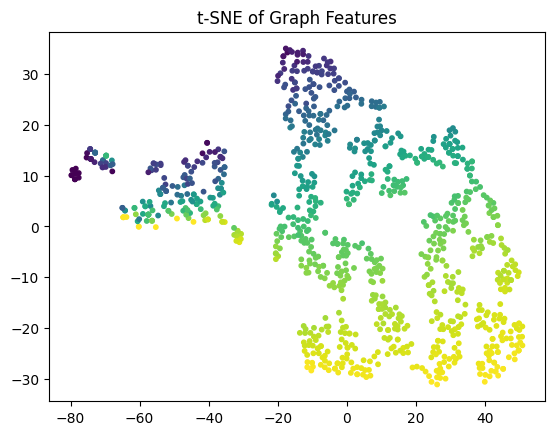

In [ ]:
# Reduce & plot
embedding = TSNE(n_components=2, perplexity=30).fit_transform(X_scaled)
# or: embedding = umap.UMAP().fit_transform(X_scaled)



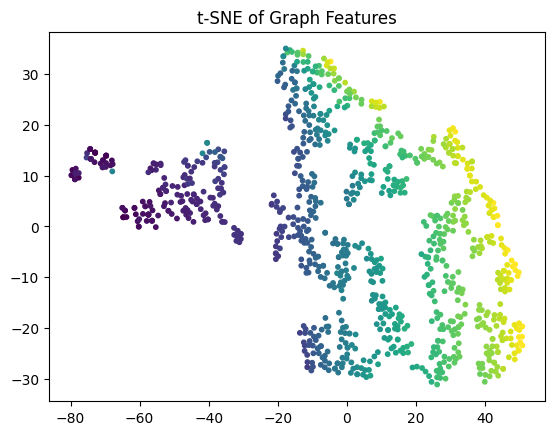

In [ ]:
plt.scatter(embedding[:, 0], embedding[:, 1], s=10, c=df['moral_density'], cmap='viridis')
plt.title("t-SNE of Graph Features")
plt.show()

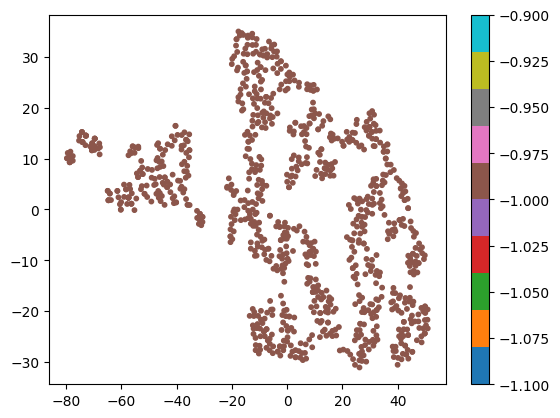

In [61]:
# # Option A: Manual bounding box
# mask = (
#     (embedding[:, 0] > x_min) & (embedding[:, 0] < x_max) &
#     (embedding[:, 1] > y_min) & (embedding[:, 1] < y_max)
# )
# island_idx = np.where(mask)[0]
# rest_idx = np.where(~mask)[0]

# Option B: Use DBSCAN to find clusters automatically
from sklearn.cluster import DBSCAN

labels = DBSCAN(eps=0.5, min_samples=10).fit_predict(embedding)
# Find which label corresponds to the island visually
plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='tab10', s=10)
plt.colorbar()
plt.show()

# Then select the island cluster
island_label = 2  # whichever label the island got
island_idx = np.where(labels == island_label)[0]
rest_idx = np.where(labels != island_label)[0]

In [59]:
np.unique(labels)

array([-1])

In [8]:
# list(nx.topological_generations(graph))

# for layer, nodes in enumerate(nx.topological_generations(graph)):
#     # `multipartite_layout` expects the layer as a node attribute, so add the
#     # numeric layer value as a node attribute
#     for node in nodes:
#         graph.nodes[node]["layer"] = layer

# pos = nx.multipartite_layout(graph, subset_key="layer")
# nx.draw_networkx(graph, pos=pos, with_labels=True)
